# Part A: Data
# Introduction
This notebook contains all code that has been used to prepare the EStreams and other data for the analysis performed in the "How landscape data quality affects our perception of dominant processes in large-sample hydrology studies?" paper by do Nascimento et al. (in review). To be able to run this notebook, please ensure that you have downloaded the acompanying data of the paper. All links can be found in the data section of the paper.

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

# Import modules

In [1]:
import pandas as pd
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.simplefilter(action='ignore', category=Warning)


# Configurations

In [2]:
# Only editable variables:
# Relative path to your local directory
PATH = "../.."

# Set the directory:
os.chdir(PATH)

path_estreams = r'/Users/nascimth/Documents/data/EStreams'

# Import data

### - Network information

In [3]:
network_estreams = pd.read_csv(path_estreams+'/streamflow_gauges/estreams_gauging_stations.csv', encoding='utf-8')
network_estreams.set_index("basin_id", inplace = True)

# Convert 'date_column' and 'time_column' to datetime
network_estreams['start_date'] = pd.to_datetime(network_estreams['start_date'])
network_estreams['end_date'] = pd.to_datetime(network_estreams['end_date'])

network_estreams

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,num_continuous_days,num_days_gaps,num_days_reliable,num_days_noflag,num_days_suspect,gauge_flag,duplicated_suspect,watershed_group,gauges_upstream,nested_catchments
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,200014,Bangs,AT,AT_EHYD,Rhein,9.534835,47.273748,9.534835,47.273748,420,...,9497,0.0,0.0,9497.0,0.0,B,['CH000197'],1,16,"['AT000001', 'CH000010', 'CH000046', 'CH000048..."
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,23103,0.0,0.0,23103.0,0.0,B,['CH000221'],1,1,['AT000002']
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,13513,0.0,0.0,13513.0,0.0,B,['CH000215'],1,2,"['AT000002', 'AT000003', 'CH000221']"
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,8765,0.0,0.0,8765.0,0.0,B,['CH000227'],1,1,['AT000004']
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,10957,0.0,0.0,10957.0,0.0,B,['CH000214'],1,3,"['AT000005', 'CH000214']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UAGR0017,6682300,BASHTANOVKA,UA,UA_GRDC,KACHA,33.894739,44.691884,33.900000,44.683333,NaN,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1988,1,['UAGR0017']
UAGR0018,6682500,YALTA,UA,UA_GRDC,DERE-KIOY,34.166667,44.500000,34.166667,44.500000,16,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1989,1,['UAGR0018']
UAGR0019,6683010,PIONERSKOE,UA,UA_GRDC,SALHYR,34.199841,44.887685,34.200000,44.883333,307,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1990,1,['UAGR0019']


###  - Signatures

In [4]:
estreams_signatures = pd.read_csv(path_estreams+'/hydroclimatic_signatures/estreams_hydrometeo_signatures.csv', encoding='utf-8')
estreams_signatures.set_index("Unnamed: 0", inplace = True)
estreams_signatures.index.name = "basin_id"

# Mapping dictionary for reclassification
time_mapping = {
    'Fall': 1, 
    'Winter': 2,  
    'Spring': 3,  
    'Summer': 4, 
}

# Reclassify time classes using the mapping dictionary
estreams_signatures['hp_time'] = estreams_signatures['hp_time'].map(time_mapping)
estreams_signatures['lp_time'] = estreams_signatures['lp_time'].map(time_mapping)

# Subset the signatures to be used (only variables, not dates and number of measurments):
estreams_signatures = estreams_signatures.iloc[:, 0:-6]
estreams_signatures

,q_mean,q_runoff_ratio,q_elas_Sankarasubramanian,slope_sawicz,baseflow_index,hfd_mean,hfd_std,q_5,q_95,hq_freq,...,aridity_pm,aridity_mk,p_seasonality,frac_snow,hp_freq,hp_dur,hp_time,lp_freq,lp_dur,lp_time
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,2.824,0.752,1.235,1.505,0.760,237.600,12.858,1.029,6.607,0.077,...,0.430,0.463,0.315,0.324,13.280,1.176,4.0,199.864,3.563,1.0
AT000002,3.898,1.083,0.920,2.467,0.720,247.952,10.932,0.980,10.727,0.964,...,0.428,0.468,0.359,0.331,16.518,1.201,4.0,208.028,3.639,1.0
AT000003,0.915,0.259,1.403,0.979,0.687,233.361,27.141,0.404,2.819,6.136,...,0.446,0.484,0.370,0.329,16.260,1.199,4.0,208.178,3.649,1.0
AT000004,5.079,1.313,0.328,2.188,0.747,242.783,10.736,1.499,13.295,0.042,...,0.428,0.453,0.342,0.380,16.847,1.210,4.0,209.780,3.653,1.0
AT000005,3.319,0.811,0.908,1.967,0.756,239.207,14.642,1.064,7.692,0.233,...,0.416,0.436,0.330,0.271,15.825,1.186,4.0,203.069,3.567,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UAGR0017,0.150,0.080,-1.875,NaN,0.354,189.111,72.114,0.000,0.797,81.511,...,NaN,1.103,-0.274,0.137,21.940,1.260,2.0,268.738,5.632,4.0
UAGR0018,0.475,0.219,2.471,NaN,0.207,160.444,42.925,0.000,3.631,60.508,...,NaN,0.971,-0.340,0.203,20.824,1.247,2.0,262.072,5.363,4.0
UAGR0019,0.312,0.155,2.972,NaN,0.354,184.667,59.422,0.000,1.412,127.517,...,NaN,0.971,-0.158,0.182,21.805,1.248,2.0,265.087,5.419,4.0


### - Vegetation

In [5]:
estreams_vegetation= pd.read_csv(path_estreams+"//attributes/static_attributes/estreams_vegetation_attributes.csv", encoding='utf-8')
estreams_vegetation.set_index("basin_id", inplace = True)

# Here we select only these two variables as representative
estreams_vegetation = estreams_vegetation[["lai_mean", "ndvi_mean"]]
estreams_vegetation

,lai_mean,ndvi_mean
basin_id,,
AT000001,0.092,0.329
AT000002,0.089,0.342
AT000003,0.087,0.313
AT000004,0.073,0.276
AT000005,0.086,0.311
...,...,...
UAGR0017,0.195,0.599
UAGR0018,0.152,0.576
UAGR0019,0.145,0.535


### - Snow cover

In [6]:
estreams_snowcover = pd.read_csv(path_estreams+"//attributes/static_attributes/estreams_snowcover_attributes.csv", encoding='utf-8')
estreams_snowcover.set_index("basin_id", inplace = True)

# Here we select only these two variables as representative
estreams_snowcover = estreams_snowcover[["sno_cov_mean"]]
estreams_snowcover

,sno_cov_mean
basin_id,
AT000001,33.844
AT000002,36.284
AT000003,36.927
AT000004,40.210
AT000005,34.486
...,...
UAGR0017,3.805
UAGR0018,6.159
UAGR0019,4.928


### - Meteorology

In [7]:
estreams_meteodensity = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_meteorology_density.csv', encoding='utf-8')
estreams_meteodensity.set_index("basin_id", inplace = True)

## Here we select only these variables as representative:
estreams_meteodensity = estreams_meteodensity[["stations_num_p_mean", "stations_num_t_mean"]]

estreams_meteodensity.head()

,stations_num_p_mean,stations_num_t_mean
basin_id,,
AT000001,22.0,23.0
AT000002,14.0,13.0
AT000003,18.0,18.0
AT000004,7.0,8.0
AT000005,10.0,10.0


### - Topography

In [8]:
estreams_topography = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_topography_attributes.csv', encoding='utf-8')
estreams_topography.set_index("basin_id", inplace = True)
estreams_topography

,ele_mt_max,ele_mt_mean,ele_mt_min,slp_dg_mean,flat_area_fra,steep_area_fra,elon_ratio,strm_dens
basin_id,,,,,,,,
AT000001,3555.408,1874.076,420.622,24.122,3.395,78.590,0.612,0.151
AT000002,2803.984,1773.178,674.209,26.095,0.463,87.662,0.539,0.151
AT000003,3293.054,1843.003,583.510,25.735,1.497,82.952,0.577,0.141
AT000004,2878.033,1890.429,1022.324,27.324,0.351,88.023,0.587,0.095
AT000005,2938.964,1772.902,567.275,28.647,1.719,83.629,0.612,0.134
...,...,...,...,...,...,...,...,...
UAGR0017,1537.278,564.291,161.399,11.810,4.283,24.393,0.634,0.129
UAGR0018,1511.835,749.565,16.793,19.438,2.114,61.735,0.621,0.024
UAGR0019,1449.416,653.127,306.877,9.655,17.055,20.545,0.739,0.112


### - Hydrology

In [9]:
estreams_hydrology = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_hydrology_attributes.csv', encoding='utf-8')
estreams_hydrology.set_index("basin_id", inplace = True)

# Here we select only these variables as representative
estreams_hydrology = estreams_hydrology[["dam_num", "res_num", "lakes_num", "lakes_tot_area", "lakes_tot_vol"]]
estreams_hydrology

,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol
basin_id,,,,,
AT000001,23.0,10.0,10.0,6.62,542.33
AT000002,0.0,0.0,0.0,0.00,0.00
AT000003,4.0,4.0,3.0,1.46,12.91
AT000004,0.0,0.0,0.0,0.00,0.00
AT000005,1.0,1.0,1.0,0.89,8.27
...,...,...,...,...,...
UAGR0017,0.0,0.0,1.0,1.43,16.43
UAGR0018,0.0,0.0,0.0,0.00,0.00
UAGR0019,0.0,0.0,1.0,0.31,1.54


### - Soils

In [10]:
estreams_soil = pd.read_csv(path_estreams+'/attributes/static_attributes/estreams_soil_attributes.csv', encoding='utf-8')
estreams_soil.set_index("basin_id", inplace = True)

# Here we select only these variables as representative
estreams_soil = estreams_soil[['root_dep_mean', 'root_dep_max', 'root_dep_min',
       'soil_tawc_mean', 'soil_fra_sand_mean', 'soil_fra_silt_mean',
       'soil_fra_clay_mean', 'soil_fra_grav_mean', 'soil_bd_mean','soil_oc_mean']]

estreams_soil

,root_dep_mean,root_dep_max,root_dep_min,soil_tawc_mean,soil_fra_sand_mean,soil_fra_silt_mean,soil_fra_clay_mean,soil_fra_grav_mean,soil_bd_mean,soil_oc_mean
basin_id,,,,,,,,,,
AT000001,81.571,130.0,0.0,28.738,58.196,16.337,7.973,9.062,1.303,1.218
AT000002,58.600,70.0,30.0,46.474,54.920,29.650,15.430,8.140,1.502,1.820
AT000003,51.660,130.0,0.0,45.044,49.262,30.836,16.883,10.294,1.425,1.714
AT000004,49.412,70.0,30.0,49.256,39.956,40.088,19.956,13.044,1.409,1.771
AT000005,31.781,100.0,0.0,44.098,39.795,38.151,20.685,17.658,1.384,1.836
...,...,...,...,...,...,...,...,...,...,...
UAGR0017,128.620,130.0,40.0,51.371,23.184,29.245,47.571,9.939,1.246,1.198
UAGR0018,73.061,130.0,40.0,64.165,30.592,39.122,30.286,7.469,1.066,2.340
UAGR0019,130.000,130.0,130.0,51.029,23.115,29.123,47.761,10.049,1.251,1.178


### - Nested catchments list
* This part has the nested catchements upstream each gauge. 

In [11]:
nested_catchments = pd.DataFrame(network_estreams.nested_catchments)
nested_catchments

,nested_catchments
basin_id,
AT000001,"['AT000001', 'CH000010', 'CH000046', 'CH000048..."
AT000002,['AT000002']
AT000003,"['AT000002', 'AT000003', 'CH000221']"
AT000004,['AT000004']
AT000005,"['AT000005', 'CH000214']"
...,...
UAGR0017,['UAGR0017']
UAGR0018,['UAGR0018']
UAGR0019,['UAGR0019']


In [12]:
nested_catchments3 = pd.DataFrame(network_estreams.duplicated_suspect)
nested_catchments3

,duplicated_suspect
basin_id,
AT000001,['CH000197']
AT000002,['CH000221']
AT000003,['CH000215']
AT000004,['CH000227']
AT000005,['CH000214']
...,...
UAGR0017,NaN
UAGR0018,NaN
UAGR0019,NaN


In [13]:
# Convert the string representation of lists to actual lists
nested_catchments['nested_catchments'] = nested_catchments['nested_catchments'].apply(lambda x: x.strip("[]").replace("'", "").split(", "))
nested_catchments

,nested_catchments
basin_id,
AT000001,"[AT000001, CH000010, CH000046, CH000048, CH000..."
AT000002,[AT000002]
AT000003,"[AT000002, AT000003, CH000221]"
AT000004,[AT000004]
AT000005,"[AT000005, CH000214]"
...,...
UAGR0017,[UAGR0017]
UAGR0018,[UAGR0018]
UAGR0019,[UAGR0019]


# Filtering the data

### - Concatenation

In [14]:
# Concatenate horizontally
network_estreams_concatenated = pd.concat([network_estreams, estreams_signatures, estreams_topography, 
                                           estreams_soil, estreams_vegetation,
                                           estreams_hydrology, estreams_snowcover, estreams_meteodensity], axis=1)

network_estreams_concatenated

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lai_mean,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,200014,Bangs,AT,AT_EHYD,Rhein,9.534835,47.273748,9.534835,47.273748,420,...,0.092,0.329,23.0,10.0,10.0,6.62,542.33,33.844,22.0,23.0
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,0.089,0.342,0.0,0.0,0.0,0.00,0.00,36.284,14.0,13.0
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,0.087,0.313,4.0,4.0,3.0,1.46,12.91,36.927,18.0,18.0
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,0.073,0.276,0.0,0.0,0.0,0.00,0.00,40.210,7.0,8.0
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,0.086,0.311,1.0,1.0,1.0,0.89,8.27,34.486,10.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UAGR0017,6682300,BASHTANOVKA,UA,UA_GRDC,KACHA,33.894739,44.691884,33.900000,44.683333,NaN,...,0.195,0.599,0.0,0.0,1.0,1.43,16.43,3.805,3.0,1.0
UAGR0018,6682500,YALTA,UA,UA_GRDC,DERE-KIOY,34.166667,44.500000,34.166667,44.500000,16,...,0.152,0.576,0.0,0.0,0.0,0.00,0.00,6.159,2.0,1.0
UAGR0019,6683010,PIONERSKOE,UA,UA_GRDC,SALHYR,34.199841,44.887685,34.200000,44.883333,307,...,0.145,0.535,0.0,0.0,1.0,0.31,1.54,4.928,1.0,0.0


## Filter 01: 
Located in a country with access to a CAMELS dataset at the time of data preparation, i.e., Austria, Czechia, Denmark, France, Germany, Great Britain, Iceland, Spain, Sweden, or Switzerland [12 019]

In [15]:
network_estreams_filtered_filter_1_countries = network_estreams_concatenated[network_estreams_concatenated["gauge_country"].isin(["AT", "CH", "CZ",
                                                                                                       "DE", "DK", "ES", "FR", 
                                                                                                       "GB", "IS", "SE"])]
network_estreams_filtered_filter_1_countries

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lai_mean,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,200014,Bangs,AT,AT_EHYD,Rhein,9.534835,47.273748,9.534835,47.273748,420,...,0.092,0.329,23.0,10.0,10.0,6.62,542.33,33.844,22.0,23.0
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,0.089,0.342,0.0,0.0,0.0,0.00,0.00,36.284,14.0,13.0
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,0.087,0.313,4.0,4.0,3.0,1.46,12.91,36.927,18.0,18.0
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,0.073,0.276,0.0,0.0,0.0,0.00,0.00,40.210,7.0,8.0
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,0.086,0.311,1.0,1.0,1.0,0.89,8.27,34.486,10.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000286,751,VASSBOTTEN,SE,SE_SMHI,ENNINGDALSÄLVEN,11.536800,58.877100,11.536800,58.877100,NaN,...,0.164,0.624,0.0,0.0,63.0,60.43,598.22,11.628,11.0,6.0
SE000287,855,GETEBRO,SE,SE_SMHI,ALSTERÅN,16.163900,56.999600,16.163900,56.999600,NaN,...,0.163,0.616,0.0,0.0,101.0,68.66,253.17,12.118,16.0,6.0
SE000288,887,SOLVEDEN,SE,SE_SMHI,SÄVEÅN,12.442300,57.875400,12.442300,57.875400,NaN,...,0.165,0.578,0.0,0.0,69.0,112.32,1473.04,13.317,15.0,6.0


## Filter 02: 
•	High-quality catchment delineation in EStreams, as described by do Nascimento et al. (2024) [10 434]

In [16]:
# Here we select only high-quality areas delineations (888 or 999 excluded):
network_estreams_filtered_filter_2_area = network_estreams_filtered_filter_1_countries[network_estreams_filtered_filter_1_countries.area_flag < 888]
network_estreams_filtered_filter_2_area

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lai_mean,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,200014,Bangs,AT,AT_EHYD,Rhein,9.534835,47.273748,9.534835,47.273748,420,...,0.092,0.329,23.0,10.0,10.0,6.62,542.33,33.844,22.0,23.0
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,0.089,0.342,0.0,0.0,0.0,0.00,0.00,36.284,14.0,13.0
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,0.087,0.313,4.0,4.0,3.0,1.46,12.91,36.927,18.0,18.0
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,0.073,0.276,0.0,0.0,0.0,0.00,0.00,40.210,7.0,8.0
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,0.086,0.311,1.0,1.0,1.0,0.89,8.27,34.486,10.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000286,751,VASSBOTTEN,SE,SE_SMHI,ENNINGDALSÄLVEN,11.536800,58.877100,11.536800,58.877100,NaN,...,0.164,0.624,0.0,0.0,63.0,60.43,598.22,11.628,11.0,6.0
SE000287,855,GETEBRO,SE,SE_SMHI,ALSTERÅN,16.163900,56.999600,16.163900,56.999600,NaN,...,0.163,0.616,0.0,0.0,101.0,68.66,253.17,12.118,16.0,6.0
SE000288,887,SOLVEDEN,SE,SE_SMHI,SÄVEÅN,12.442300,57.875400,12.442300,57.875400,NaN,...,0.165,0.578,0.0,0.0,69.0,112.32,1473.04,13.317,15.0,6.0


## Filter 03: 
•	Catchment area (obtained from EStreams) below 2000 km2 [9115]

In [17]:
# Area threshold (in km2):
network_estreams_filtered_filter_3_areasize = network_estreams_filtered_filter_2_area[network_estreams_filtered_filter_2_area.area_estreams <= 2000]
network_estreams_filtered_filter_3_areasize

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lai_mean,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,0.089,0.342,0.0,0.0,0.0,0.00,0.00,36.284,14.0,13.0
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,0.087,0.313,4.0,4.0,3.0,1.46,12.91,36.927,18.0,18.0
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,0.073,0.276,0.0,0.0,0.0,0.00,0.00,40.210,7.0,8.0
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,0.086,0.311,1.0,1.0,1.0,0.89,8.27,34.486,10.0,10.0
AT000006,200105,Garsella,AT,AT_EHYD,Lutz,9.875898,47.226658,9.875898,47.226658,730,...,0.097,0.356,0.0,0.0,0.0,0.00,0.00,33.031,15.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000283,654,ERSBO,SE,SE_SMHI,VÄSTERDALÄLVEN,13.011000,61.307600,13.011000,61.307600,NaN,...,0.070,0.334,0.0,0.0,15.0,3.35,14.59,35.366,10.0,6.0
SE000286,751,VASSBOTTEN,SE,SE_SMHI,ENNINGDALSÄLVEN,11.536800,58.877100,11.536800,58.877100,NaN,...,0.164,0.624,0.0,0.0,63.0,60.43,598.22,11.628,11.0,6.0
SE000287,855,GETEBRO,SE,SE_SMHI,ALSTERÅN,16.163900,56.999600,16.163900,56.999600,NaN,...,0.163,0.616,0.0,0.0,101.0,68.66,253.17,12.118,16.0,6.0


## Filter 04: 
•	No redundancy among the EStreams catchments (the catchment with the longer streamflow time series was kept) [8909]

### - Duplicated suspects deletion
- At this part, when there is a duplicated suspect in our catchments list we keep only the catchemnt with the longest time-series.
- For example, FR001479 has 23 years of measurements, from 1969 to 1991, and has two duplicated suspects: [FR001477, FR001478].
- After our filter, we aim to keep only FR001479 in our final list, since it is the one with the longest number of measurements from the three.
- Eventually we mitigate the number of potential duplicates in our time-series.

In [18]:
# Remove the brackets and handle NaN values
network_estreams_filtered_filter_3_areasize['duplicated_suspect'] = network_estreams_filtered_filter_3_areasize['duplicated_suspect'].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else x
)

In [19]:
# Step 1: Filter rows where `duplicated_suspect` is not NaN
filtered_df = network_estreams_filtered_filter_3_areasize[network_estreams_filtered_filter_3_areasize['duplicated_suspect'].notna()]

# Step 2: Create a dictionary to store the maximum `num_years` for each group (current row and corresponding row(s))
max_num_years_dict = {}
processed_indices = set()  # Set to keep track of processed indices

# Iterate through each row in the filtered DataFrame
for index, row in filtered_df.iterrows():
    # Check if the current index has already been processed
    if index in processed_indices:
        continue  # Skip processing this row

    # Get the `duplicated_suspect` values, assuming it might be a list or a single string index
    duplicate_indices = row['duplicated_suspect']

    # If `duplicated_suspect` is a string, convert it to a list of strings and strip whitespace
    if isinstance(duplicate_indices, str):
        duplicate_indices = [dup.strip() for dup in duplicate_indices.split(',')]  # Split and strip whitespace

    # Initialize the maximum `num_years` as the current row's `num_years`
    max_num_years = row['num_years']
    max_index = index  # Start with the current index as the max index

    # Compare `num_years` of the current row with each duplicate index
    for dup_index in duplicate_indices:
        # Check if the duplicate index has already been processed
        if dup_index in processed_indices:
            continue  # Skip processing this duplicate index

        try:
            # Get `num_years` of the duplicate row
            num_years_duplicate = network_estreams_filtered_filter_3_areasize.loc[dup_index, 'num_years']

            # Compare the `num_years` and update max values if necessary
            if num_years_duplicate > max_num_years:
                max_num_years = num_years_duplicate
                max_index = dup_index  # Update max index
        except KeyError:
            # Handle KeyError if the duplicate index is not found in the DataFrame
            continue

    # Store the maximum `num_years` and corresponding index in the dictionary
    max_num_years_dict[max_index] = max_num_years

    # Add the indices to the processed set
    processed_indices.add(index)
    for dup_index in duplicate_indices:
        processed_indices.add(dup_index)

# Step 3: Filter the DataFrame to keep only the rows with the indices in max_num_years_dict keys
result_df = network_estreams_filtered_filter_3_areasize.loc[list(max_num_years_dict.keys())]

# Step 4: Get the indices of the rows in `result_df`
result_df_indices = set(result_df.index)

# Step 5: Get the indices of rows without duplicates (where `duplicated_suspect` is NaN)
no_duplicates_indices = set(network_estreams_filtered_filter_3_areasize[network_estreams_filtered_filter_3_areasize['duplicated_suspect'].isna()].index)

# Step 6: Combine the indices from `result_df` and rows without duplicates
indices_to_keep = list(result_df_indices.union(no_duplicates_indices))

# Step 7: Filter `network_estreams_filtered` using the combined indices
network_estreams_filtered_filter_4_redundancy = network_estreams_filtered_filter_3_areasize.loc[indices_to_keep]

network_estreams_filtered_filter_4_redundancy

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lai_mean,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000528,212092,Bruehl,AT,AT_EHYD,Isel,12.549894,46.975420,12.549894,46.975420,920,...,0.068,0.223,0.0,0.0,0.0,0.00,0.00,40.641,15.0,14.0
DEBY0876,56000500,Hof,DE,DE_BY,Sächsische Saale,11.846397,50.186210,11.846397,50.186210,516.07,...,0.133,0.550,0.0,0.0,0.0,0.00,0.00,11.397,16.0,3.0
ES000101,2000,VINUESA,ES,ES_CEDEX,NaN,-2.757610,41.911260,-2.757610,41.911260,1090,...,0.187,0.657,0.0,0.0,0.0,0.00,0.00,7.028,0.0,0.0
GB000624,81007,Water of Fleet at Rusko,GB,GB_NRFA,Water of Fleet at Rusko,-4.200000,54.910000,-4.200000,54.910000,7.6,...,0.146,0.594,0.0,0.0,1.0,0.16,0.90,5.028,0.0,0.0
FR001300,M005061020,M0050620,FR,FR_EAUFRANCE,La Sarthe à Mieuxcé et à Saint-Céneri-le-Gérei,-0.023533,48.385887,-0.023533,48.385887,121,...,0.149,0.662,0.0,0.0,1.0,0.15,0.36,1.231,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000232,2422,HÄLLERED,SE,SE_SMHI,HÄLLEREDSÅN,12.739500,57.788200,12.739500,57.788200,NaN,...,0.146,0.585,0.0,0.0,5.0,1.65,5.86,14.281,2.0,2.0
FR000230,B610000801,NaN,FR,FR_EAUFRANCE,La Semoy en Belgique [Straimont],5.381465,49.793077,5.381465,49.793077,345,...,0.188,0.651,0.0,0.0,0.0,0.00,0.00,5.495,4.0,0.0
DK000740,45000103,NYBORG LDV.-ODENSE,DK,DK_ODA,LINDVED Å,10.453267,55.392152,10.453267,55.392152,NaN,...,0.116,0.531,0.0,0.0,0.0,0.00,0.00,5.455,1.0,1.0


## Filter 05: 
•	Availability of at least 90 % of the Epot data between October 1990 and September 2015 [8846]

In [20]:
import tqdm as tqdm

# Dictionary to store NaN counts per basin_id
nan_counts_dict = {}

for basin_id in tqdm.tqdm(network_estreams_filtered_filter_4_redundancy.index):
    data = pd.read_csv(path_estreams+"//time_series_csv//estreams_timeseries_"+basin_id+".csv", index_col=0)

    #data["q_mean"] = timeseries_estreams[basin_id]
    #data.to_csv(r"C:\Users\nascimth\Documents\Thiago\Eawag\Python\Data\data"+"\estreams_timeseries_"+basin_id+".csv")

    #output_folder = f"results\hbv\{basin_id}"  # Folder named after the basin_id
    #txt_filename = os.path.join(output_folder, "ptq_estreams.txt")
    #txt_filename_evap = os.path.join(output_folder, "evap_estreams.txt")

    #zip_filename = f"results\hbv\{basin_id}.zip"

    ## Create the output folder
    #os.makedirs(output_folder, exist_ok=True)

    # Ensure the required columns exist
    required_columns = ["p_mean", "t_mean", "q_mean"]
    df_selected = data[required_columns].copy()

    df_selected.index = pd.to_datetime(df_selected.index)

    df_selected = df_selected.loc["1990-10-01":"2015-09-30"]

    # Format the date index to YYYYMMDD
    df_selected.insert(0, "date", df_selected.index.strftime("%Y%m%d"))

    df_selected.columns = ["Date", "P", "T", "Q"]

    df_pet = data.loc["1990-10-01":"2015-09-30", "pet_mean"].copy()

    # Count NaN values in P and T
    nan_counts_dict[basin_id] = {
        "P": df_selected["P"].isna().sum(),
        "T": df_selected["T"].isna().sum(),
        "evap": df_pet.isna().sum(),
        "Q": df_selected["Q"].isna().sum()
        }

# Convert dictionary to DataFrame
nan_counts_df = pd.DataFrame.from_dict(nan_counts_dict, orient="index").reset_index()
nan_counts_df.rename(columns={"index": "basin_id"}, inplace=True)

100%|██████████| 8909/8909 [05:08<00:00, 28.90it/s]


In [24]:
from datetime import datetime

start = datetime.strptime("01.10.1990", "%d.%m.%Y")
end = datetime.strptime("30.09.2015", "%d.%m.%Y")

num_days = (end - start).days + 1  # +1 to include both start and end dates
print(f"Number of days: {num_days}")

nan_counts_df[["P_perc", "T_perc", "evap_perc", "Q_perc"]] = 100*(nan_counts_df[["P", "T", "evap", "Q"]]/9131)

nan_counts_df[(nan_counts_df.evap_perc <= 10)]

Number of days: 9131


,basin_id,P,T,evap,Q,P_perc,T_perc,evap_perc,Q_perc
0,AT000528,0,0,0,0,0.0,0.0,0.000000,0.000000
1,DEBY0876,0,0,0,0,0.0,0.0,0.000000,0.000000
2,ES000101,0,0,0,882,0.0,0.0,0.000000,9.659402
3,GB000624,0,0,2,0,0.0,0.0,0.021903,0.000000
4,FR001300,0,0,0,0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
8904,SE000232,0,0,0,4,0.0,0.0,0.000000,0.043807
8905,FR000230,0,0,0,9131,0.0,0.0,0.000000,100.000000
8906,DK000740,0,0,3,9131,0.0,0.0,0.032855,100.000000
8907,FR000077,0,0,0,3191,0.0,0.0,0.000000,34.946884


In [25]:
network_estreams_filtered_filter_4_redundancy["evap_perc"] = nan_counts_df.set_index("basin_id", inplace=False)["evap_perc"]
network_estreams_filtered_filter_5_evap= network_estreams_filtered_filter_4_redundancy[network_estreams_filtered_filter_4_redundancy.evap_perc <= 10]

network_estreams_filtered_filter_5_evap

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean,evap_perc
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000528,212092,Bruehl,AT,AT_EHYD,Isel,12.549894,46.975420,12.549894,46.975420,920,...,0.223,0.0,0.0,0.0,0.00,0.00,40.641,15.0,14.0,0.000000
DEBY0876,56000500,Hof,DE,DE_BY,Sächsische Saale,11.846397,50.186210,11.846397,50.186210,516.07,...,0.550,0.0,0.0,0.0,0.00,0.00,11.397,16.0,3.0,0.000000
ES000101,2000,VINUESA,ES,ES_CEDEX,NaN,-2.757610,41.911260,-2.757610,41.911260,1090,...,0.657,0.0,0.0,0.0,0.00,0.00,7.028,0.0,0.0,0.000000
GB000624,81007,Water of Fleet at Rusko,GB,GB_NRFA,Water of Fleet at Rusko,-4.200000,54.910000,-4.200000,54.910000,7.6,...,0.594,0.0,0.0,1.0,0.16,0.90,5.028,0.0,0.0,0.021903
FR001300,M005061020,M0050620,FR,FR_EAUFRANCE,La Sarthe à Mieuxcé et à Saint-Céneri-le-Gérei,-0.023533,48.385887,-0.023533,48.385887,121,...,0.662,0.0,0.0,1.0,0.15,0.36,1.231,6.0,6.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000232,2422,HÄLLERED,SE,SE_SMHI,HÄLLEREDSÅN,12.739500,57.788200,12.739500,57.788200,NaN,...,0.585,0.0,0.0,5.0,1.65,5.86,14.281,2.0,2.0,0.000000
FR000230,B610000801,NaN,FR,FR_EAUFRANCE,La Semoy en Belgique [Straimont],5.381465,49.793077,5.381465,49.793077,345,...,0.651,0.0,0.0,0.0,0.00,0.00,5.495,4.0,0.0,0.000000
DK000740,45000103,NYBORG LDV.-ODENSE,DK,DK_ODA,LINDVED Å,10.453267,55.392152,10.453267,55.392152,NaN,...,0.531,0.0,0.0,0.0,0.00,0.00,5.455,1.0,1.0,0.032855


## Filter 06: 
•	Availability of the catchment in one of the CAMELS datasets [3557]

In [26]:
# Filter made by Franziska with the previous basins
with open("../../data/catchment_list_3563.txt", "r") as file:
    catchment_list = [line.strip() for line in file]
catchment_list = catchment_list[1:]

len(catchment_list)

3563

In [27]:
network_estreams_filtered_filter_6_camels = network_estreams_filtered_filter_4_redundancy.loc[catchment_list]
network_estreams_filtered_filter_6_camels["evap_perc"] = nan_counts_df.set_index("basin_id", inplace=False)["evap_perc"]
network_estreams_filtered_filter_6_camels= network_estreams_filtered_filter_6_camels[network_estreams_filtered_filter_6_camels.evap_perc <= 10]

network_estreams_filtered_filter_6_camels

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean,evap_perc
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,0.342,0.0,0.0,0.0,0.00,0.00,36.284,14.0,13.0,0.000000
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,0.313,4.0,4.0,3.0,1.46,12.91,36.927,18.0,18.0,0.000000
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,0.311,1.0,1.0,1.0,0.89,8.27,34.486,10.0,10.0,0.010952
AT000006,200105,Garsella,AT,AT_EHYD,Lutz,9.875898,47.226658,9.875898,47.226658,730,...,0.356,0.0,0.0,0.0,0.00,0.00,33.031,15.0,14.0,0.000000
AT000007,231688,Beschling,AT,AT_EHYD,Ill,9.678850,47.200301,9.678850,47.200301,485,...,0.362,7.0,6.0,5.0,2.67,23.90,32.887,40.0,38.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000252,257,MUNKEDAL 2,SE,SE_SMHI,ÖREKILSÄLVEN,11.683300,58.463600,11.683300,58.463600,NaN,...,0.622,0.0,0.0,36.0,19.61,216.56,11.133,10.0,5.0,0.000000
SE000277,364,HILLARED,SE,SE_SMHI,ÄTRAN,13.141300,57.607300,13.141300,57.607300,NaN,...,0.597,0.0,0.0,29.0,50.78,541.40,13.610,12.0,8.0,0.000000
SE000283,654,ERSBO,SE,SE_SMHI,VÄSTERDALÄLVEN,13.011000,61.307600,13.011000,61.307600,NaN,...,0.334,0.0,0.0,15.0,3.35,14.59,35.366,10.0,6.0,0.000000


## Filter 07: 
•	CAMELS forcing data coming from a ground-based estimate (Austria is therefore excluded) [3097]

In [30]:
network_estreams_filtered_filter_7_ground = network_estreams_filtered_filter_6_camels[network_estreams_filtered_filter_6_camels.gauge_country != "AT"]
network_estreams_filtered_filter_7_ground

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean,evap_perc
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000006,2020,Bellinzona,CH,CH_CAMELS,Ticino,9.0100,46.1900,9.0100,46.1900,222,...,0.402,12.0,5.0,6.0,2.53,175.39,25.186,4.0,11.0,0.0
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,0.272,7.0,5.0,3.0,1.88,153.40,38.068,3.0,2.0,0.0
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,0.626,0.0,0.0,0.0,0.00,0.00,7.300,2.0,2.0,0.0
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,0.608,2.0,1.0,2.0,0.41,1.37,11.867,9.0,7.0,0.0
CH000014,2053,Martigny-Pont_de_Rossettan,CH,CH_CAMELS,Drance,7.0600,46.1000,7.0600,46.1000,482,...,0.241,4.0,2.0,2.0,1.42,231.60,39.710,2.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE000252,257,MUNKEDAL 2,SE,SE_SMHI,ÖREKILSÄLVEN,11.6833,58.4636,11.6833,58.4636,NaN,...,0.622,0.0,0.0,36.0,19.61,216.56,11.133,10.0,5.0,0.0
SE000277,364,HILLARED,SE,SE_SMHI,ÄTRAN,13.1413,57.6073,13.1413,57.6073,NaN,...,0.597,0.0,0.0,29.0,50.78,541.40,13.610,12.0,8.0,0.0
SE000283,654,ERSBO,SE,SE_SMHI,VÄSTERDALÄLVEN,13.0110,61.3076,13.0110,61.3076,NaN,...,0.334,0.0,0.0,15.0,3.35,14.59,35.366,10.0,6.0,0.0


## Filter 08: 
•	Average streamflow (in the CAMELS dataset) between October 1995 and September 2015 below 10 mm d-1 [3097]

In [31]:
network_estreams_filtered_filter_8_ground = network_estreams_filtered_filter_7_ground.copy()

## Filter 09: 
•	Number of lakes upstream (obtained from EStreams) below or equal to 5 [2841] 

In [32]:
network_estreams_filtered_filter_9_lakes = network_estreams_filtered_filter_8_ground[network_estreams_filtered_filter_8_ground.lakes_num < 5]

network_estreams_filtered_filter_9_lakes

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,ndvi_mean,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean,evap_perc
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,0.272,7.0,5.0,3.0,1.88,153.40,38.068,3.0,2.0,0.000000
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,0.626,0.0,0.0,0.0,0.00,0.00,7.300,2.0,2.0,0.000000
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,0.608,2.0,1.0,2.0,0.41,1.37,11.867,9.0,7.0,0.000000
CH000014,2053,Martigny-Pont_de_Rossettan,CH,CH_CAMELS,Drance,7.0600,46.1000,7.0600,46.1000,482,...,0.241,4.0,2.0,2.0,1.42,231.60,39.710,2.0,3.0,0.000000
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,0.244,6.0,3.0,2.0,0.93,101.00,40.691,5.0,4.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000670,96004,Strathmore at Allnabad,GB,GB_NRFA,Strathmore at Allnabad,-4.6400,58.3500,-4.6400,58.3500,21.9,...,0.430,0.0,0.0,2.0,0.37,2.64,14.557,1.0,0.0,0.054759
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,0.582,0.0,0.0,2.0,0.92,2.16,10.109,10.0,8.0,0.000000
SE000044,1635,KLIPPAN 2,SE,SE_SMHI,BÄLJANE Å,13.1072,56.1438,13.1072,56.1438,NaN,...,0.619,0.0,0.0,3.0,0.69,2.16,8.946,4.0,2.0,0.000000


## Filter 10: 
•	Normalized upstream below or equal to 0.2 [2741]

In [33]:
# Compute the additional hydrological attributes
network_estreams_filtered_filter_9_lakes["lakes_depth_mean"] = network_estreams_filtered_filter_9_lakes.lakes_tot_vol / network_estreams_filtered_filter_9_lakes.lakes_tot_area
network_estreams_filtered_filter_9_lakes["lakes_depth_mean_norm"] = (network_estreams_filtered_filter_9_lakes.lakes_tot_vol / network_estreams_filtered_filter_9_lakes.area_estreams)*1000
network_estreams_filtered_filter_9_lakes["q_mean_yr"]= network_estreams_filtered_filter_9_lakes.q_mean*365
network_estreams_filtered_filter_9_lakes["p_mean_yr"]= network_estreams_filtered_filter_9_lakes.p_mean*365

network_estreams_filtered_filter_9_lakes["norm_ups_cap"]= network_estreams_filtered_filter_9_lakes["lakes_depth_mean_norm"]/network_estreams_filtered_filter_9_lakes["p_mean_yr"]

In [34]:
network_estreams_filtered_filter_10_norm = network_estreams_filtered_filter_9_lakes[network_estreams_filtered_filter_9_lakes.norm_ups_cap <= 0.2]

network_estreams_filtered_filter_10_norm

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,lakes_tot_vol,sno_cov_mean,stations_num_p_mean,stations_num_t_mean,evap_perc,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,153.40,38.068,3.0,2.0,0.000000,81.595745,198.137712,1346.120,1565.120,0.126596
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,0.00,7.300,2.0,2.0,0.000000,NaN,0.000000,590.570,1144.640,0.000000
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,1.37,11.867,9.0,7.0,0.000000,3.341463,0.804983,866.875,1196.470,0.000673
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,101.00,40.691,5.0,4.0,0.000000,108.602151,121.193649,1627.535,1584.100,0.076506
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,0.00,17.737,0.0,0.0,0.000000,NaN,0.000000,836.580,1258.885,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,1.46,9.600,1.0,0.0,0.010952,3.041667,7.533112,811.030,948.635,0.007941
GB000670,96004,Strathmore at Allnabad,GB,GB_NRFA,Strathmore at Allnabad,-4.6400,58.3500,-4.6400,58.3500,21.9,...,2.64,14.557,1.0,0.0,0.054759,7.135135,25.055759,2170.290,1380.795,0.018146
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,2.16,10.109,10.0,8.0,0.000000,2.347826,3.255513,299.300,689.120,0.004724


## Filter 11: 
•	Runoff ratio (in the CAMELS dataset) between October 1995 and September 2015 below 1.1 [2741]

In [35]:
runoff_ratios_camels_and_estreams_2741 = pd.read_csv("results/runoff_ratios_camels_and_estreams_2741.txt", sep="\t")
runoff_ratios_camels_and_estreams_2741.set_index("id", inplace = True)
runoff_ratios_camels_and_estreams_2741

,Q_cam_by_P_estr,Q_cam_by_P_cam
id,,
CH000010,0.834265,0.872254
CH000011,0.521699,0.474978
CH000013,0.717178,0.624626
CH000015,1.005801,0.960978
CH000019,0.701906,0.555753
...,...,...
GB000668,0.829819,0.710839
GB000670,1.364437,0.854633
SE000014,0.418766,0.369256


In [36]:
network_estreams_filtered_filter_10_norm["Q_cam_by_P_estr"] = runoff_ratios_camels_and_estreams_2741["Q_cam_by_P_estr"]
network_estreams_filtered_filter_10_norm["Q_cam_by_P_cam"] = runoff_ratios_camels_and_estreams_2741["Q_cam_by_P_cam"]

In [37]:
network_estreams_filtered_filter_11_runoff = network_estreams_filtered_filter_10_norm[network_estreams_filtered_filter_10_norm.Q_cam_by_P_cam<=1.1]
network_estreams_filtered_filter_11_runoff

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,stations_num_p_mean,stations_num_t_mean,evap_perc,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,Q_cam_by_P_estr,Q_cam_by_P_cam
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,3.0,2.0,0.000000,81.595745,198.137712,1346.120,1565.120,0.126596,0.834265,0.872254
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,2.0,2.0,0.000000,NaN,0.000000,590.570,1144.640,0.000000,0.521699,0.474978
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,9.0,7.0,0.000000,3.341463,0.804983,866.875,1196.470,0.000673,0.717178,0.624626
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,5.0,4.0,0.000000,108.602151,121.193649,1627.535,1584.100,0.076506,1.005801,0.960978
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,0.0,0.0,0.000000,NaN,0.000000,836.580,1258.885,0.000000,0.701906,0.555753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,1.0,0.0,0.010952,3.041667,7.533112,811.030,948.635,0.007941,0.829819,0.710839
GB000670,96004,Strathmore at Allnabad,GB,GB_NRFA,Strathmore at Allnabad,-4.6400,58.3500,-4.6400,58.3500,21.9,...,1.0,0.0,0.054759,7.135135,25.055759,2170.290,1380.795,0.018146,1.364437,0.854633
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,10.0,8.0,0.000000,2.347826,3.255513,299.300,689.120,0.004724,0.418766,0.369256


## Filter 12: 
•	Runoff ratio (in the EStreams dataset) between October 1995 and September 2015 below 1.1 [2682]

In [38]:
network_estreams_filtered_filter_12_runoff = network_estreams_filtered_filter_11_runoff[network_estreams_filtered_filter_11_runoff.Q_cam_by_P_estr<=1.1]
network_estreams_filtered_filter_12_runoff

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,stations_num_p_mean,stations_num_t_mean,evap_perc,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,Q_cam_by_P_estr,Q_cam_by_P_cam
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,3.0,2.0,0.000000,81.595745,198.137712,1346.120,1565.120,0.126596,0.834265,0.872254
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,2.0,2.0,0.000000,NaN,0.000000,590.570,1144.640,0.000000,0.521699,0.474978
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,9.0,7.0,0.000000,3.341463,0.804983,866.875,1196.470,0.000673,0.717178,0.624626
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,5.0,4.0,0.000000,108.602151,121.193649,1627.535,1584.100,0.076506,1.005801,0.960978
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,0.0,0.0,0.000000,NaN,0.000000,836.580,1258.885,0.000000,0.701906,0.555753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,1.0,1.0,0.076662,7.290076,68.616673,2424.330,2064.805,0.033232,1.068201,0.876906
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,1.0,0.0,0.010952,3.041667,7.533112,811.030,948.635,0.007941,0.829819,0.710839
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,10.0,8.0,0.000000,2.347826,3.255513,299.300,689.120,0.004724,0.418766,0.369256


## Figure

In [39]:
# World map
world = gpd.read_file(r"/Users/nascimth/Documents/data/gis/world.shp")

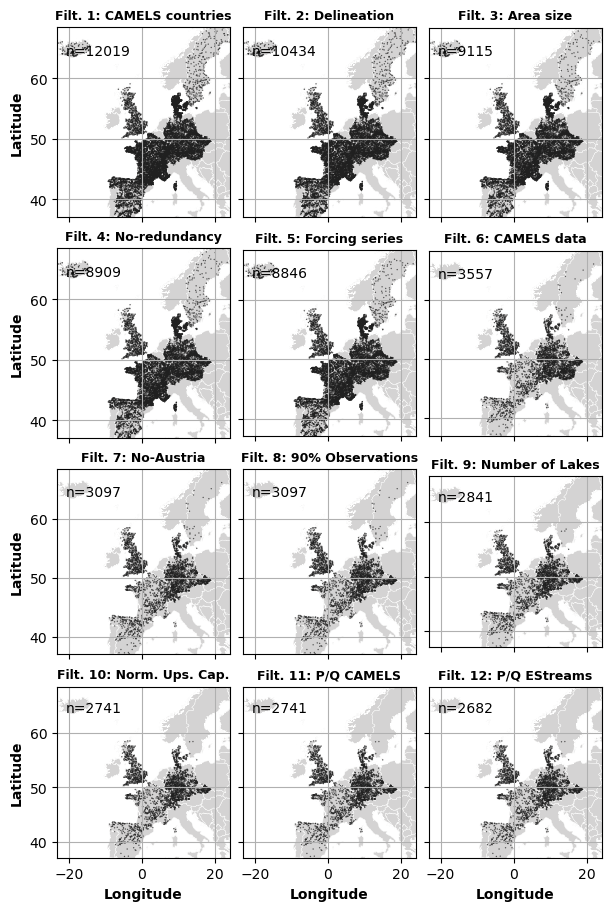

In [42]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
titles = ["CAMELS countries", "Delineation", "Area size", "No-redundancy", "Forcing series", "CAMELS data", "No-Austria", "90% Observations", "Number of Lakes", "Norm. Ups. Cap.", "P/Q CAMELS", "P/Q EStreams" ]
# --- Put all 12 DataFrames in a list
dfs = [network_estreams_filtered_filter_1_countries, network_estreams_filtered_filter_2_area, 
       network_estreams_filtered_filter_3_areasize, network_estreams_filtered_filter_4_redundancy, 
       network_estreams_filtered_filter_5_evap, network_estreams_filtered_filter_6_camels, 
       network_estreams_filtered_filter_7_ground, network_estreams_filtered_filter_8_ground, 
       network_estreams_filtered_filter_9_lakes, network_estreams_filtered_filter_10_norm, 
       network_estreams_filtered_filter_11_runoff, network_estreams_filtered_filter_12_runoff]

# --- Create figure with 2 columns × 6 rows
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(6, 9), sharex=True, sharey=True,
    constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()
j = 0
# --- Loop through all DataFrames
for i, (ax, df) in enumerate(zip(axes, dfs)):
    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84 lat/lon
    )
    if j == 0:
        X_MIN, X_MAX, Y_MIN, Y_MAX = gdf["lon"].min(), gdf["lon"].max(), gdf["lat"].min(), gdf["lat"].max()

    # Plot base world map
    world.plot(ax=ax, color="#C1C0BFAF", edgecolor="white", linewidth=0.3)
    
    # Plot the points
    gdf.plot(ax=ax, color="#202020AC", markersize=1, alpha=0.7, edgecolor="none")
    
    # Clean up look
    ax.set_title(f"Filt. {j+1}: {titles[j]}", fontsize=9, fontweight="bold")
    #ax.set_axis_off()
    ax.grid(True)
    ax.text(
            0.05, 0.875,
            f"n={len(gdf)}",
            transform=ax.transAxes,
            fontsize=10,
            ha="left", va="center",
            color="black",)
    

    if j == 9 or j==10 or j==11: 
        ax.set_xlabel("Longitude", fontweight="bold")

    if j == 0: 
        ax.set_ylabel("Latitude", fontweight="bold")
    elif j == 3: 
        ax.set_ylabel("Latitude", fontweight="bold")
    elif j == 6: 
        ax.set_ylabel("Latitude", fontweight="bold")
    elif j == 9: 
        ax.set_ylabel("Latitude", fontweight="bold")
    
    ax.grid(True)

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)

    j = j + 1

# Hide any unused axes (if fewer than 12)
for ax in axes[len(dfs):]:
    ax.set_visible(False)

#plt.tight_layout()
plt.savefig("results/figs/S1_filters_stations.png", dpi=300, bbox_inches='tight')

plt.show()

## Export subset
- Here we export our subset of data (i.e., timeseries_discharge and network_attributes).

In [ ]:
network_estreams_filtered_filter_12_runoff.to_csv(
    "data/runoff_ratios_camels_and_estreams_2682_filtered_rr.txt",
    sep="\t"
)

# End